## House Price Prediction

In [66]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [67]:
data = pd.read_csv("House Price India.csv")

In [68]:
data

,id,Date,number of bedrooms,number of bathrooms,living area,lot area,number of floors,waterfront present,number of views,condition of the house,...,Built Year,Renovation Year,Postal Code,Lattitude,Longitude,living_area_renov,lot_area_renov,Number of schools nearby,Distance from the airport,Price
0,6762810635,42491,4,2.50,2920,4000,1.5,0,0,5,...,1909,0,122004,52.8878,-114.470,2470,4000,2,51,1400000
1,6762810998,42491,5,2.75,2910,9480,1.5,0,0,3,...,1939,0,122004,52.8852,-114.468,2940,6600,1,53,1200000
2,6762812605,42491,4,2.50,3310,42998,2.0,0,0,3,...,2001,0,122005,52.9532,-114.321,3350,42847,3,76,838000
3,6762812919,42491,3,2.00,2710,4500,1.5,0,0,4,...,1929,0,122006,52.9047,-114.485,2060,4500,1,51,805000
4,6762813105,42491,3,2.50,2600,4750,1.0,0,0,4,...,1951,0,122007,52.9133,-114.590,2380,4750,1,67,790000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14614,6762830250,42734,2,1.50,1556,20000,1.0,0,0,4,...,1957,0,122066,52.6191,-114.472,2250,17286,3,76,221700
14615,6762830339,42734,3,2.00,1680,7000,1.5,0,0,4,...,1968,0,122072,52.5075,-114.393,1540,7480,3,59,219200
14616,6762830618,42734,2,1.00,1070,6120,1.0,0,0,3,...,1962,0,122056,52.7289,-114.507,1130,6120,2,64,209000
14617,6762830709,42734,4,1.00,1030,6621,1.0,0,0,4,...,1955,0,122042,52.7157,-114.411,1420,6631,3,54,205000


### Basic Checks

In [69]:
data.head()

,id,Date,number of bedrooms,number of bathrooms,living area,lot area,number of floors,waterfront present,number of views,condition of the house,...,Built Year,Renovation Year,Postal Code,Lattitude,Longitude,living_area_renov,lot_area_renov,Number of schools nearby,Distance from the airport,Price
0,6762810635,42491,4,2.50,2920,4000,1.5,0,0,5,...,1909,0,122004,52.8878,-114.470,2470,4000,2,51,1400000
1,6762810998,42491,5,2.75,2910,9480,1.5,0,0,3,...,1939,0,122004,52.8852,-114.468,2940,6600,1,53,1200000
2,6762812605,42491,4,2.50,3310,42998,2.0,0,0,3,...,2001,0,122005,52.9532,-114.321,3350,42847,3,76,838000
3,6762812919,42491,3,2.00,2710,4500,1.5,0,0,4,...,1929,0,122006,52.9047,-114.485,2060,4500,1,51,805000
4,6762813105,42491,3,2.50,2600,4750,1.0,0,0,4,...,1951,0,122007,52.9133,-114.590,2380,4750,1,67,790000


In [70]:
data.tail()

,id,Date,number of bedrooms,number of bathrooms,living area,lot area,number of floors,waterfront present,number of views,condition of the house,...,Built Year,Renovation Year,Postal Code,Lattitude,Longitude,living_area_renov,lot_area_renov,Number of schools nearby,Distance from the airport,Price
14614,6762830250,42734,2,1.5,1556,20000,1.0,0,0,4,...,1957,0,122066,52.6191,-114.472,2250,17286,3,76,221700
14615,6762830339,42734,3,2.0,1680,7000,1.5,0,0,4,...,1968,0,122072,52.5075,-114.393,1540,7480,3,59,219200
14616,6762830618,42734,2,1.0,1070,6120,1.0,0,0,3,...,1962,0,122056,52.7289,-114.507,1130,6120,2,64,209000
14617,6762830709,42734,4,1.0,1030,6621,1.0,0,0,4,...,1955,0,122042,52.7157,-114.411,1420,6631,3,54,205000
14618,6762831463,42734,3,1.0,900,4770,1.0,0,0,3,...,1969,2009,122018,52.5338,-114.552,900,3480,2,55,146000


In [71]:
data.shape

(14619, 23)

In [72]:
data.columns

Index(['id', 'Date', 'number of bedrooms', 'number of bathrooms',
       'living area', 'lot area', 'number of floors', 'waterfront present',
       'number of views', 'condition of the house', 'grade of the house',
       'Area of the house(excluding basement)', 'Area of the basement',
       'Built Year', 'Renovation Year', 'Postal Code', 'Lattitude',
       'Longitude', 'living_area_renov', 'lot_area_renov',
       'Number of schools nearby', 'Distance from the airport', 'Price'],
      dtype='str')

In [73]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 14619 entries, 0 to 14618
Data columns (total 23 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     14619 non-null  int64  
 1   Date                                   14619 non-null  int64  
 2   number of bedrooms                     14619 non-null  int64  
 3   number of bathrooms                    14619 non-null  float64
 4   living area                            14619 non-null  int64  
 5   lot area                               14619 non-null  int64  
 6   number of floors                       14619 non-null  float64
 7   waterfront present                     14619 non-null  int64  
 8   number of views                        14619 non-null  int64  
 9   condition of the house                 14619 non-null  int64  
 10  grade of the house                     14619 non-null  int64  
 11  Area of the h

In [74]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
id,14619.0,6.762821e+09,6237.161975,6.762810e+09,6.762815e+09,6.762821e+09,6.762826e+09,6.762832e+09
Date,14619.0,4.260455e+04,67.343747,4.249100e+04,4.254600e+04,4.260000e+04,4.266200e+04,4.273400e+04
number of bedrooms,14619.0,3.379233e+00,0.938655,1.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,3.300000e+01
number of bathrooms,14619.0,2.129557e+00,0.769955,5.000000e-01,1.750000e+00,2.250000e+00,2.500000e+00,8.000000e+00
living area,14619.0,2.098157e+03,928.218740,3.700000e+02,1.440000e+03,1.930000e+03,2.570000e+03,1.354000e+04
lot area,14619.0,1.509369e+04,37920.885355,5.200000e+02,5.010500e+03,7.620000e+03,1.080000e+04,1.074218e+06
number of floors,14619.0,1.502326e+00,0.540241,1.000000e+00,1.000000e+00,1.500000e+00,2.000000e+00,3.500000e+00
waterfront present,14619.0,7.661263e-03,0.087196,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
number of views,14619.0,2.328477e-01,0.765651,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.000000e+00
condition of the house,14619.0,3.430399e+00,0.664047,1.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,5.000000e+00


In [75]:
data.duplicated().sum()

0

In [76]:
data.isnull().sum()

id                                       0
Date                                     0
number of bedrooms                       0
number of bathrooms                      0
living area                              0
lot area                                 0
number of floors                         0
waterfront present                       0
number of views                          0
condition of the house                   0
grade of the house                       0
Area of the house(excluding basement)    0
Area of the basement                     0
Built Year                               0
Renovation Year                          0
Postal Code                              0
Lattitude                                0
Longitude                                0
living_area_renov                        0
lot_area_renov                           0
Number of schools nearby                 0
Distance from the airport                0
Price                                    0
dtype: int6

In [77]:
data.drop(["Postal Code", "Lattitude", "Longitude","living_area_renov", "lot_area_renov"],axis=1,inplace=True)

In [78]:
data.shape

(14619, 18)

### EDA

In [79]:
data.groupby("condition of the house")["Price"].mean()

condition of the house
1    285497.222222
2    312891.400000
3    539336.477968
4    521082.494579
5    609954.024276
Name: Price, dtype: float64

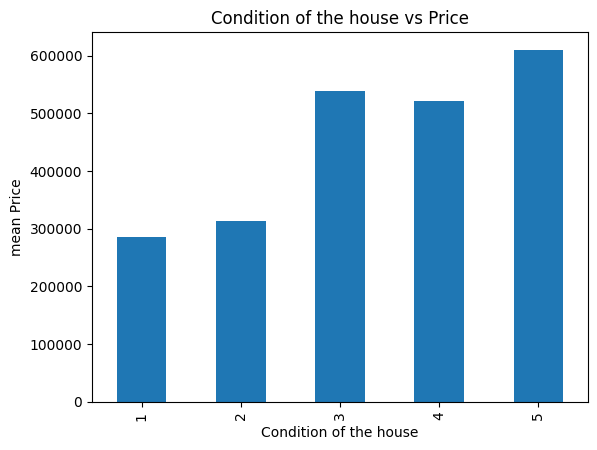

In [80]:
data.groupby("condition of the house")["Price"].mean().plot(kind="bar")
plt.title("Condition of the house vs Price")
plt.ylabel("mean Price")
plt.xlabel("Condition of the house")
plt.show()

In [81]:
data.groupby("Built Year")["Price"].mean()

Built Year
1900    594690.147541
1901    567673.428571
1902    703760.000000
1903    477744.757576
1904    614994.607143
            ...      
2011    555079.489796
2012    515258.864078
2013    686037.215385
2014    676779.834158
2015    465650.500000
Name: Price, Length: 116, dtype: float64

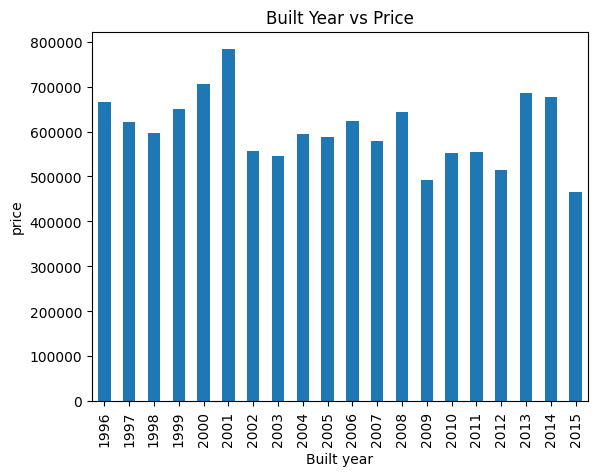

In [82]:
data.groupby("Built Year")["Price"].mean().tail(20).plot(kind="bar")
plt.title("Built Year vs Price")
plt.xlabel("Built year")
plt.ylabel("price")
plt.show()

In [83]:
data.columns

Index(['id', 'Date', 'number of bedrooms', 'number of bathrooms',
       'living area', 'lot area', 'number of floors', 'waterfront present',
       'number of views', 'condition of the house', 'grade of the house',
       'Area of the house(excluding basement)', 'Area of the basement',
       'Built Year', 'Renovation Year', 'Number of schools nearby',
       'Distance from the airport', 'Price'],
      dtype='str')

In [84]:
data["grade of the house"].value_counts()

grade of the house
7     6011
8     4137
9     1828
6     1324
10     803
11     280
5      154
12      55
4       17
13      10
Name: count, dtype: int64

In [85]:
data.groupby("Area of the house(excluding basement)")["Price"].max()

Area of the house(excluding basement)
370      276000
380      245000
420      280000
430       80000
440      290000
         ...   
7680    7060000
8020    3300000
8570    7700000
8860    6890000
9410    2280000
Name: Price, Length: 781, dtype: int64

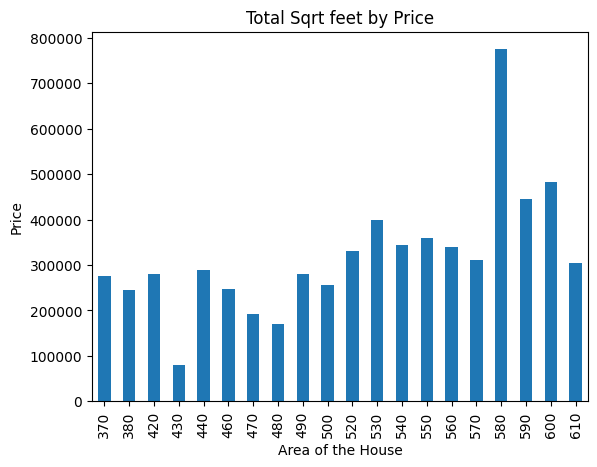

In [86]:
data.groupby("Area of the house(excluding basement)")["Price"].max().head(20).plot(kind="bar")
plt.title("Total Sqrt feet by Price")
plt.xlabel("Area of the House")
plt.ylabel("Price")
plt.show()

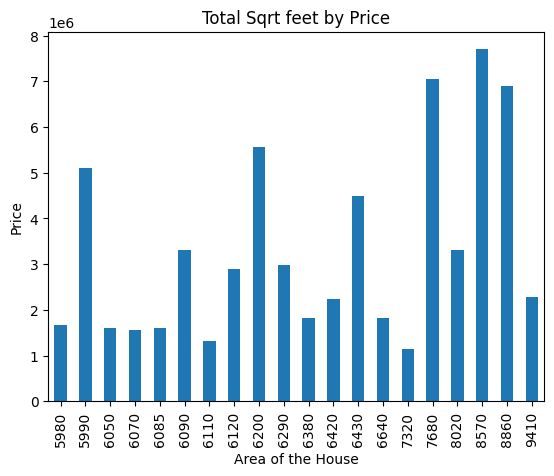

In [87]:
data.groupby("Area of the house(excluding basement)")["Price"].max().tail(20).plot(kind="bar")
plt.title("Total Sqrt feet by Price")
plt.xlabel("Area of the House")
plt.ylabel("Price")
plt.show()

In [88]:
data.groupby("grade of the house")["Price"].max()

grade of the house
4      355000
5      775000
6     1200000
7     1650000
8     3070000
9     2700000
10    3600000
11    7060000
12    5110000
13    7700000
Name: Price, dtype: int64

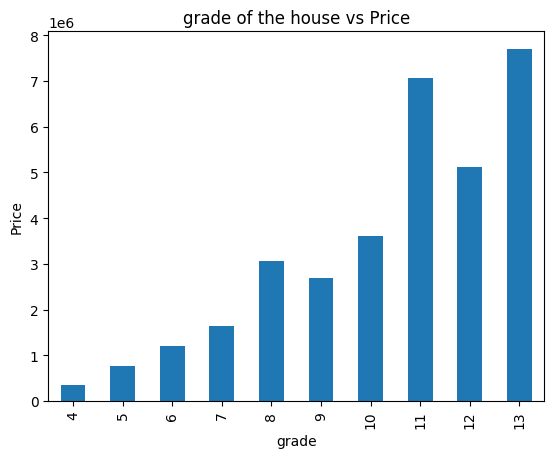

In [89]:
data.groupby("grade of the house")["Price"].max().plot(kind="bar")
plt.title("grade of the house vs Price")
plt.xlabel("grade")
plt.ylabel("Price")
plt.show()

In [90]:
data.groupby("number of bedrooms")["Price"].min()

number of bedrooms
1      80000
2      78000
3      82000
4     100000
5     133000
6     175000
7     280000
8     340000
9     450000
10    650000
11    520000
33    640000
Name: Price, dtype: int64

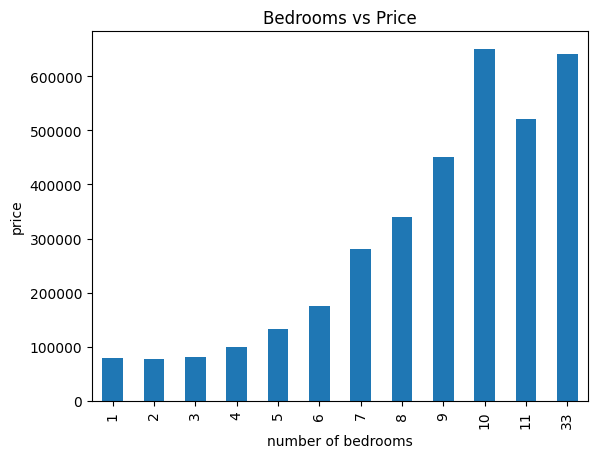

In [91]:
data.groupby("number of bedrooms")["Price"].min().plot(kind="bar")
plt.title("Bedrooms vs Price")
plt.xlabel("number of bedrooms")
plt.ylabel("price")
plt.show()

### Feature selection

In [92]:
data.columns

Index(['id', 'Date', 'number of bedrooms', 'number of bathrooms',
       'living area', 'lot area', 'number of floors', 'waterfront present',
       'number of views', 'condition of the house', 'grade of the house',
       'Area of the house(excluding basement)', 'Area of the basement',
       'Built Year', 'Renovation Year', 'Number of schools nearby',
       'Distance from the airport', 'Price'],
      dtype='str')

In [93]:
x = data[["number of bedrooms",'number of bathrooms','living area','condition of the house','Number of schools nearby']]
y = data[["Price"]]

### Scaling

In [94]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [95]:
x = scaler.fit_transform(x)

In [96]:
x

array([[ 0.66135967,  0.48113899,  0.88542843,  2.36377066, -0.01498174],
       [ 1.72674998,  0.80584451,  0.87465474, -0.64816722, -1.23854654],
       [ 0.66135967,  0.48113899,  1.30560238, -0.64816722,  1.20858305],
       ...,
       [-1.46942094, -1.46709411, -1.10770444, -0.64816722, -0.01498174],
       [ 0.66135967, -1.46709411, -1.1507992 ,  0.85780172,  1.20858305],
       [-0.40403064, -1.46709411, -1.29085719, -0.64816722, -0.01498174]])

### Train Test Split

In [97]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

In [98]:
x_train.shape

(11695, 5)

In [99]:
x_test.shape

(2924, 5)

In [100]:
y_train.shape

(11695, 1)

In [101]:
y_test.shape

(2924, 1)

### Model

In [102]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

### Linear Regression

In [103]:
lr = LinearRegression()

In [104]:
lr.fit(x_train,y_train)

LinearRegression()

In [105]:
y_pred = lr.predict(x_test)

In [106]:
mean_squared_error(y_pred, y_test)

59251188714.51087

In [107]:
mean_absolute_error(y_pred,y_test)

165051.87129704005

### Decision Tree 

In [108]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor

In [109]:
param_grid = {
    "criterion" : ["mse", "friedman_mse", "mea"],
    "splitter" : ["best", "random"],
    "max_depth" : [None, 10, 20, 30, 40, 50],
    "min_samples_split" : [2, 5, 10],
    "min_samples_leaf" : [1,2,4]
}

In [110]:
tree_model = DecisionTreeRegressor()

In [111]:
grid_tree = GridSearchCV(estimator= tree_model, param_grid = param_grid)

In [112]:
grid_tree.fit(x_train, y_train)

GridSearchCV(estimator=DecisionTreeRegressor(),
             param_grid={'criterion': ['mse', 'friedman_mse', 'mea'],
                         'max_depth': [None, 10, 20, 30, 40, 50],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'splitter': ['best', 'random']})

In [113]:
grid_tree.best_params_

{'criterion': 'friedman_mse',
 'max_depth': 10,
 'min_samples_leaf': 4,
 'min_samples_split': 5,
 'splitter': 'random'}

In [114]:
tree_preds = grid_tree.predict(x_test)

In [115]:
mean_squared_error(y_test, tree_preds)

62811518790.21206

In [116]:
mean_absolute_error(y_test, tree_preds)

163053.88885995586

### Random Forest Regressor

In [117]:
from sklearn.ensemble import RandomForestRegressor
rfmodel = RandomForestRegressor()

In [118]:
param_gridrf = {
    "max_depth" : [5,10,15],
    "n_estimators" : [2,3,4,5,6,7,8,9,10]
}

In [119]:
gridrf = GridSearchCV(estimator= rfmodel, param_grid= param_gridrf)

In [120]:
gridrf.fit(x_train, y_train)

GridSearchCV(estimator=RandomForestRegressor(),
             param_grid={'max_depth': [5, 10, 15],
                         'n_estimators': [2, 3, 4, 5, 6, 7, 8, 9, 10]})

In [121]:
gridrf.best_params_

{'max_depth': 5, 'n_estimators': 10}

In [122]:
rf_pred = gridrf.predict(x_test)

In [123]:
mean_squared_error(rf_pred, y_test)

57887313460.45584

In [124]:
mean_absolute_error(rf_pred, y_test)

159392.56618371283

In [125]:
import joblib
joblib.dump(gridrf,"model.pkl")

['model.pkl']